<a href="https://colab.research.google.com/github/maheshgenai22/Python-code-for-scrape-product-details-/blob/main/Student_Placement_Prediction.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [5]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

from sklearn.model_selection import train_test_split
from sklearn.preprocessing import StandardScaler, LabelEncoder
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

print("Libraries imported successfully!")

Libraries imported successfully!


In [6]:
df = pd.read_csv("student_placement_dataset.csv")

df.head()

,Student_ID,CGPA,10th_Percentage,12th_Percentage,Backlogs,Attendance,Coding_Score,Aptitude_Score,Communication_Score,Internship,Projects,Certifications,Hackathon,Placement_Status
0,STU1001,7.90,88.99,65.57,2,64.93,64.14,37.79,75.93,No,3,1,No,Placed
1,STU1002,7.26,84.25,71.41,1,62.02,84.23,81.68,35.00,Yes,1,2,Yes,Not Placed
2,STU1003,8.05,75.60,64.28,0,71.70,66.06,54.84,83.28,No,4,1,Yes,Not Placed
3,STU1004,8.92,68.53,69.61,0,85.32,55.23,79.85,88.67,No,2,2,Yes,Placed
4,STU1005,7.17,81.98,52.17,0,76.03,56.62,65.97,56.35,No,3,4,No,Placed


In [7]:
print("Dataset Shape:", df.shape)

print("\nColumns:")
print(df.columns.tolist())

print("\nMissing Values:")
print(df.isnull().sum())

print("\nDuplicate Rows:", df.duplicated().sum())

Dataset Shape: (1000, 14)

Columns:
['Student_ID', 'CGPA', '10th_Percentage', '12th_Percentage', 'Backlogs', 'Attendance', 'Coding_Score', 'Aptitude_Score', 'Communication_Score', 'Internship', 'Projects', 'Certifications', 'Hackathon', 'Placement_Status']

Missing Values:
Student_ID             0
CGPA                   0
10th_Percentage        0
12th_Percentage        0
Backlogs               0
Attendance             0
Coding_Score           0
Aptitude_Score         0
Communication_Score    0
Internship             0
Projects               0
Certifications         0
Hackathon              0
Placement_Status       0
dtype: int64

Duplicate Rows: 0


Placement_Status
Placed        673
Not Placed    327
Name: count, dtype: int64


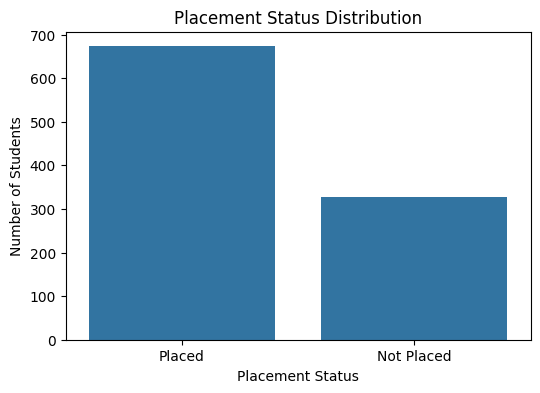

In [9]:
print(df["Placement_Status"].value_counts())

plt.figure(figsize=(6, 4))
sns.countplot(data=df, x="Placement_Status")
plt.title("Placement Status Distribution")
plt.xlabel("Placement Status")
plt.ylabel("Number of Students")
plt.show()

In [10]:
df.describe()

,CGPA,10th_Percentage,12th_Percentage,Backlogs,Attendance,Coding_Score,Aptitude_Score,Communication_Score,Projects,Certifications
count,1000.000000,1000.00000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000,1000.000000
mean,7.419190,75.67184,73.016360,0.654000,77.861710,67.135810,66.446320,70.110180,1.961000,1.552000
std,0.968597,9.88216,10.604819,0.786704,9.568418,14.795932,15.395381,13.344276,1.420386,1.217694
min,5.000000,45.60000,45.000000,0.000000,50.000000,30.000000,30.000000,35.000000,0.000000,0.000000
25%,6.750000,68.93500,65.875000,0.000000,71.425000,57.310000,55.755000,60.867500,1.000000,1.000000
50%,7.425000,75.63000,72.995000,0.000000,78.160000,67.065000,66.360000,69.840000,2.000000,1.000000
75%,8.050000,82.29250,80.270000,1.000000,84.712500,77.362500,77.495000,79.560000,3.000000,2.000000
max,10.000000,98.00000,98.000000,4.000000,98.000000,100.000000,100.000000,100.000000,6.000000,6.000000


In [11]:
# Convert categorical columns into numerical values

df["Internship"] = df["Internship"].map({
    "Yes": 1,
    "No": 0
})

df["Hackathon"] = df["Hackathon"].map({
    "Yes": 1,
    "No": 0
})

df["Placement_Status"] = df["Placement_Status"].map({
    "Placed": 1,
    "Not Placed": 0
})

# Check the updated dataset
df.head()

,Student_ID,CGPA,10th_Percentage,12th_Percentage,Backlogs,Attendance,Coding_Score,Aptitude_Score,Communication_Score,Internship,Projects,Certifications,Hackathon,Placement_Status
0,STU1001,7.90,88.99,65.57,2,64.93,64.14,37.79,75.93,0,3,1,0,1
1,STU1002,7.26,84.25,71.41,1,62.02,84.23,81.68,35.00,1,1,2,1,0
2,STU1003,8.05,75.60,64.28,0,71.70,66.06,54.84,83.28,0,4,1,1,0
3,STU1004,8.92,68.53,69.61,0,85.32,55.23,79.85,88.67,0,2,2,1,1
4,STU1005,7.17,81.98,52.17,0,76.03,56.62,65.97,56.35,0,3,4,0,1


In [12]:
df.dtypes

,0
Student_ID,object
CGPA,float64
10th_Percentage,float64
12th_Percentage,float64
Backlogs,int64
Attendance,float64
Coding_Score,float64
Aptitude_Score,float64
Communication_Score,float64
Internship,int64


In [13]:
X = df.drop(["Student_ID", "Placement_Status"], axis=1)
y = df["Placement_Status"]

print("Features Shape:", X.shape)
print("Target Shape:", y.shape)

Features Shape: (1000, 12)
Target Shape: (1000,)


In [14]:
X_train, X_test, y_train, y_test = train_test_split(
    X,
    y,
    test_size=0.2,
    random_state=42,
    stratify=y
)

print("Training data:", X_train.shape)
print("Testing data:", X_test.shape)

Training data: (800, 12)
Testing data: (200, 12)


In [15]:
from sklearn.preprocessing import StandardScaler

scaler = StandardScaler()

X_train_scaled = scaler.fit_transform(X_train)
X_test_scaled = scaler.transform(X_test)

print("Scaling completed successfully!")
print("X_train shape:", X_train_scaled.shape)
print("X_test shape:", X_test_scaled.shape)

Scaling completed successfully!
X_train shape: (800, 12)
X_test shape: (200, 12)


In [16]:
from sklearn.linear_model import LogisticRegression
from sklearn.metrics import accuracy_score, classification_report, confusion_matrix

logistic_model = LogisticRegression(random_state=42)

logistic_model.fit(X_train_scaled, y_train)

y_pred_logistic = logistic_model.predict(X_test_scaled)

accuracy_logistic = accuracy_score(y_test, y_pred_logistic)

print("Logistic Regression Accuracy:",
      round(accuracy_logistic * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_logistic))

Logistic Regression Accuracy: 68.0 %

Classification Report:
              precision    recall  f1-score   support

           0       0.53      0.15      0.24        65
           1       0.70      0.93      0.80       135

    accuracy                           0.68       200
   macro avg       0.61      0.54      0.52       200
weighted avg       0.64      0.68      0.62       200



In [17]:
from sklearn.tree import DecisionTreeClassifier

# Create Decision Tree model
decision_tree = DecisionTreeClassifier(
    random_state=42,
    max_depth=5
)

# Train model
decision_tree.fit(X_train, y_train)

# Prediction
y_pred_tree = decision_tree.predict(X_test)

# Accuracy
accuracy_tree = accuracy_score(y_test, y_pred_tree)

print("Decision Tree Accuracy:",
      round(accuracy_tree * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_tree))

Decision Tree Accuracy: 64.5 %

Classification Report:
              precision    recall  f1-score   support

           0       0.42      0.25      0.31        65
           1       0.70      0.84      0.76       135

    accuracy                           0.65       200
   macro avg       0.56      0.54      0.54       200
weighted avg       0.61      0.65      0.61       200



In [18]:
from sklearn.ensemble import RandomForestClassifier

# Create Random Forest model
random_forest = RandomForestClassifier(
    n_estimators=200,
    random_state=42
)

# Train the model
random_forest.fit(X_train, y_train)

# Prediction
y_pred_rf = random_forest.predict(X_test)

# Accuracy
accuracy_rf = accuracy_score(y_test, y_pred_rf)

print("Random Forest Accuracy:",
      round(accuracy_rf * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_rf))

Random Forest Accuracy: 67.5 %

Classification Report:
              precision    recall  f1-score   support

           0       0.50      0.11      0.18        65
           1       0.69      0.95      0.80       135

    accuracy                           0.68       200
   macro avg       0.59      0.53      0.49       200
weighted avg       0.63      0.68      0.60       200



In [19]:
from sklearn.neighbors import KNeighborsClassifier

# Create KNN model
knn_model = KNeighborsClassifier(n_neighbors=7)

# Train model
knn_model.fit(X_train_scaled, y_train)

# Prediction
y_pred_knn = knn_model.predict(X_test_scaled)

# Accuracy
accuracy_knn = accuracy_score(y_test, y_pred_knn)

print("KNN Accuracy:",
      round(accuracy_knn * 100, 2), "%")

print("\nClassification Report:")
print(classification_report(y_test, y_pred_knn))

KNN Accuracy: 63.0 %

Classification Report:
              precision    recall  f1-score   support

           0       0.38      0.22      0.27        65
           1       0.69      0.83      0.75       135

    accuracy                           0.63       200
   macro avg       0.53      0.52      0.51       200
weighted avg       0.59      0.63      0.60       200




Logistic Regression
[[ 10  55]
 [  9 126]]


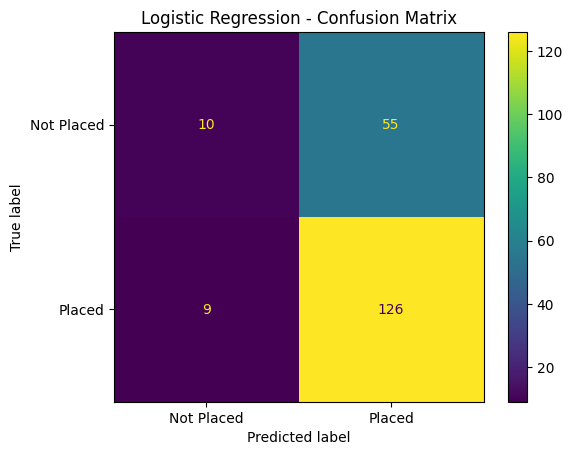


Decision Tree
[[ 16  49]
 [ 22 113]]


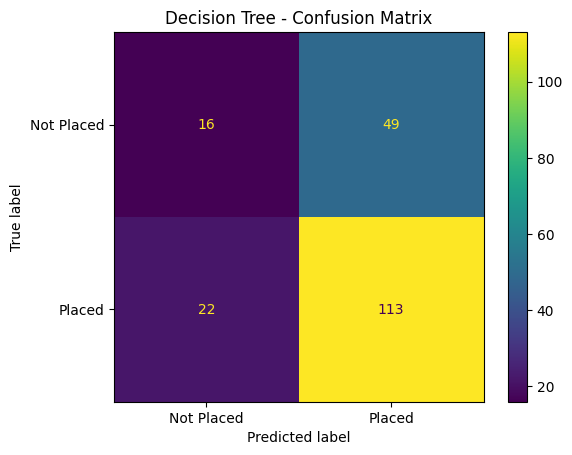


Random Forest
[[  7  58]
 [  7 128]]


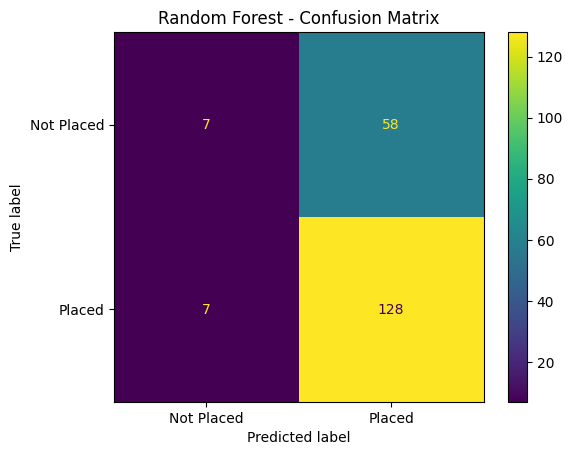


KNN
[[ 14  51]
 [ 23 112]]


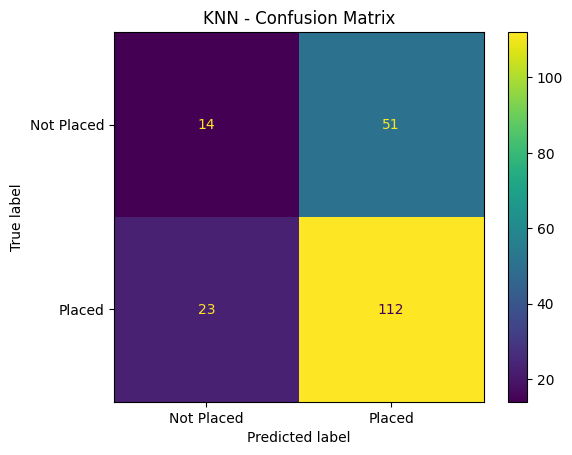

In [20]:
from sklearn.metrics import ConfusionMatrixDisplay

models = {
    "Logistic Regression": (y_test, y_pred_logistic),
    "Decision Tree": (y_test, y_pred_tree),
    "Random Forest": (y_test, y_pred_rf),
    "KNN": (y_test, y_pred_knn)
}

for name, (y_true, y_pred) in models.items():
    print("\n", "=" * 50)
    print(name)
    print("=" * 50)

    cm = confusion_matrix(y_true, y_pred)
    print(cm)

    ConfusionMatrixDisplay(
        confusion_matrix=cm,
        display_labels=["Not Placed", "Placed"]
    ).plot()

    plt.title(f"{name} - Confusion Matrix")
    plt.show()

                Feature  Importance
1       10th_Percentage    0.126406
0                  CGPA    0.123379
5          Coding_Score    0.123286
6        Aptitude_Score    0.122010
7   Communication_Score    0.115663
2       12th_Percentage    0.110623
4            Attendance    0.108989
3              Backlogs    0.046959
9              Projects    0.046859
10       Certifications    0.042986
8            Internship    0.018045
11            Hackathon    0.014796


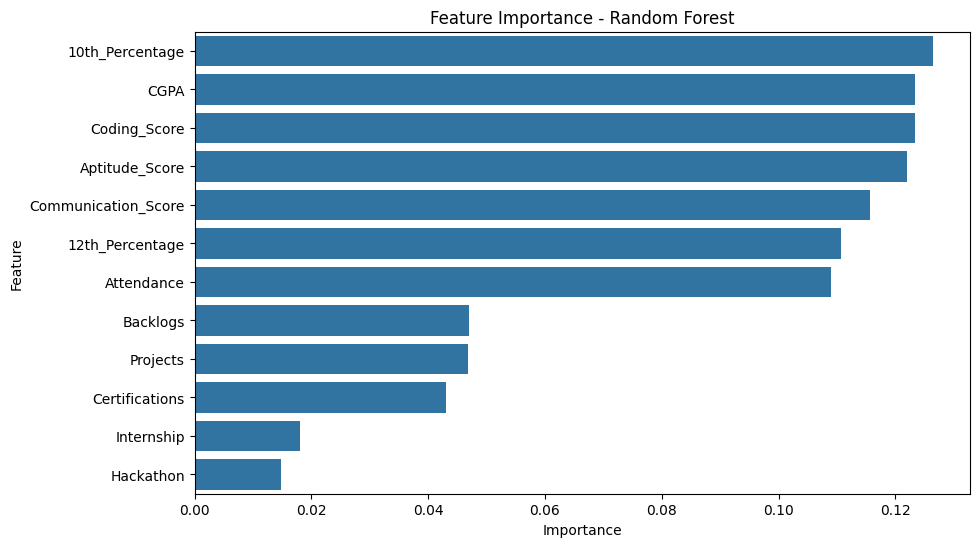

In [21]:
# Get feature importance from Random Forest

feature_importance = pd.DataFrame({
    "Feature": X.columns,
    "Importance": random_forest.feature_importances_
})

# Sort from highest to lowest
feature_importance = feature_importance.sort_values(
    by="Importance",
    ascending=False
)

print(feature_importance)

# Plot
plt.figure(figsize=(10, 6))

sns.barplot(
    data=feature_importance,
    x="Importance",
    y="Feature"
)

plt.title("Feature Importance - Random Forest")
plt.xlabel("Importance")
plt.ylabel("Feature")
plt.show()

In [22]:
import joblib

# Save the trained Logistic Regression model
joblib.dump(logistic_model, "placement_model.pkl")

# Save the scaler
joblib.dump(scaler, "scaler.pkl")

print("Model saved successfully!")
print("Scaler saved successfully!")

Model saved successfully!
Scaler saved successfully!


In [23]:
import os

print(os.listdir())

['.config', 'student_placement_dataset.csv', 'scaler.pkl', 'placement_model.pkl', 'sample_data']


In [24]:
import joblib

joblib.dump(logistic_model, "placement_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Files created successfully!")

import os

print("Model size:", os.path.getsize("placement_model.pkl"), "bytes")
print("Scaler size:", os.path.getsize("scaler.pkl"), "bytes")

Files created successfully!
Model size: 959 bytes
Scaler size: 1335 bytes


In [25]:
from google.colab import files
import joblib

# Save model
joblib.dump(logistic_model, "placement_model.pkl")

# Save scaler
joblib.dump(scaler, "scaler.pkl")

print("Files created successfully!")

# Download model
files.download("placement_model.pkl")

Files created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [26]:
from google.colab import files

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [27]:
from google.colab import files
import joblib

joblib.dump(logistic_model, "placement_model.pkl")
joblib.dump(scaler, "scaler.pkl")

print("Files created successfully!")

files.download("placement_model.pkl")

Files created successfully!


<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>

In [28]:
from google.colab import files

files.download("scaler.pkl")

<IPython.core.display.Javascript object>

<IPython.core.display.Javascript object>